<a href="https://colab.research.google.com/github/ArduinoPLUS/aicar/blob/main/gd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0.2, 4 - 결과값에 못미침

0.2, 10 - 디폴트(엔터 2 번 입력 결과값 2에 근접(2.024)

0.5, 1 - 처음 시도로 기울기 0 지점 도착

0.9, 9 - 좌우 진동하며 기울기 0 점 도착

1.0, 5 - 좌우 진동 고정

1.05, 3 - 좌우 진동하며 발산 시작 0.8

학습율(0.01-1.05 범위)을 입력하고 [ENTER]를 누르세요:
학습회수(1 이상)을 입력하고 [ENTER]를 누르세요:
01   현재 x:  5.800   현재 y: 20.440   부호(진행방향)/미분:  7.600   다음 x:  4.280
02   현재 x:  4.280   현재 y: 11.198   부호(진행방향)/미분:  4.560   다음 x:  3.368
03   현재 x:  3.368   현재 y:  7.871   부호(진행방향)/미분:  2.736   다음 x:  2.821
04   현재 x:  2.821   현재 y:  6.674   부호(진행방향)/미분:  1.642   다음 x:  2.492
05   현재 x:  2.492   현재 y:  6.243   부호(진행방향)/미분:  0.985   다음 x:  2.295
06   현재 x:  2.295   현재 y:  6.087   부호(진행방향)/미분:  0.591   다음 x:  2.177
07   현재 x:  2.177   현재 y:  6.031   부호(진행방향)/미분:  0.355   다음 x:  2.106
08   현재 x:  2.106   현재 y:  6.011   부호(진행방향)/미분:  0.213   다음 x:  2.064
09   현재 x:  2.064   현재 y:  6.004   부호(진행방향)/미분:  0.128   다음 x:  2.038
10   현재 x:  2.038   현재 y:  6.001   부호(진행방향)/미분:  0.077   다음 x:  2.023

학습율: 0.2   학습회수: 10 



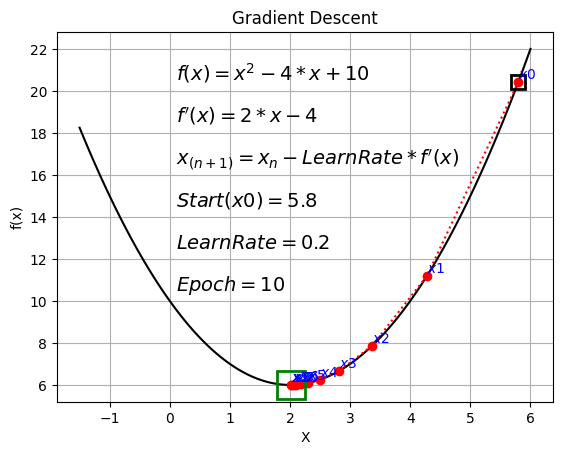

In [2]:
# 그래디언트 디센트(Gradient Descent) 경사하강법                         <gd.py>

import numpy as np
import matplotlib.pyplot as plt

START = 5.8                           # 학습 시작 값

def func(x):                          # 함수 f(x)
  return x**2 - 4*x + 10

def grad_func(x):                     # f(x)의 미분 함수 f'(x)
  return 2*x - 4

x = np.linspace(-1.5, 6, 100)         # 정의역(domain), -1.5 부터 6 까지 100 개 점
y = func(x)                           # 함수 계산, 100개 y 값

# 미분에 의한 경사하강법 -------------------------------------------------------
def gradient_descent(func, grad_func, x0, learning_rate=0.01, MaxIter=10, verbose=True):
  paths = [START,]
  for i in range(MaxIter):
    f = func(x0)
    g = grad_func(x0)
    x1 = x0 - learning_rate * g
    if verbose:
      print(f'{i+1:02d}   현재 x:{x0:7.3f}   현재 y:{f:7.3f}   부호(진행방향)/미분:{
            g:7.3f}   다음 x:{x1:7.3f}')
    x0 = x1
    paths.append(x0)
  print()
  return(np.array(paths))

# 학습율, 학습회수 입력 --------------------------------------------------------
a = input('학습율(0.01-1.05 범위)을 입력하고 [ENTER]를 누르세요:')
if a == '': a = 0.2
a = float(a)

m = input('학습회수(1 이상)을 입력하고 [ENTER]를 누르세요:')
if m == '': m = 10
m = int(m)

# 경로 계산 --------------------------------------------------------------------
paths = gradient_descent(func, grad_func, START, learning_rate=a, MaxIter=m)
# 함수 그래프 ------------------------------------------------------------------
plt.plot(x, y, 'k-')
# 경로 표시
plt.plot(paths, func(paths), 'ro:')
plt.plot(paths[0], func(paths[0]), 'ks', markersize=10,
         markeredgewidth=2, markerfacecolor='none')
# 위치 표시
for k, point in enumerate(paths):
  plt.text(point, func(point), f'$x{k}$', verticalalignment='bottom', color='blue')
print('학습율:',a,'  학습회수:',m,'\n')
# 최종 위치
plt.plot(paths[-1], func(paths[-1]), 'gs', markersize=20,
         markeredgewidth=2, markerfacecolor='none')
plt.grid()
plt.xlabel('X')
plt.ylabel('f(x)')
plt.title('Gradient Descent')
plt.text(0.1,20.5, r'$f(x) = x^2 - 4*x + 10$', fontdict={'size': 14})
plt.text(0.1,18.5, r"$f'(x) = 2*x - 4$", fontdict={'size': 14})
plt.text(0.1,16.5, r"$x_{(n+1)} = x_{n} - LearnRate * f'(x)$", fontdict={'size': 14})
plt.text(0.1,14.5, f'$Start(x0)= {START}$', fontdict={'size': 14})
plt.text(0.1,12.5, f'$LearnRate = {a}$', fontdict={'size': 14})
plt.text(0.1,10.5, f'$Epoch = {m}$', fontdict={'size': 14})
plt.show()
